# Stage 09 — Route-level environmental exposure POC

## Purpose

Stage 08 identified the strongest proof-of-concept H3 cases where:

- observed activity is relatively important;
- activity is relatively persistent;
- access to high-green-view opportunities is comparatively weaker.

Stage 09 now demonstrates the final technical step:

> **For a small number of strongest H3 cases, what environmental conditions are encountered along the route to the selected high-green-view opportunity?**

For each selected H3 case, this notebook:

1. identifies the nearest high-green-view destination;
2. creates a CAFEIN route from the H3 origin to that destination;
3. reports route-level:
   - PM₂.₅,
   - Green View,
   - road noise;
4. compares the fastest bicycle route with an illustrative PM₂.₅-weighted alternative route.

## Critical interpretation caveat

The CAFEIN Helsinki PM₂.₅ raster is a **single FMI-ENFUSER model-hour sample**.

Therefore:

- this notebook demonstrates the **route-exposure machinery**;
- it does **not** estimate historical PM₂.₅ exposure for the Locomizer dates;
- PM₂.₅ values here should be described as **technical sample-hour exposure context**.

The Green View and road-noise layers also come from the CAFEIN Helsinki sample and should be interpreted according to their own source periods and coverage.


## 1. Imports and paths

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rioxarray

import cafein.sampledata.helsinki as helsinki
from cafein import DetailedItineraries, Exposure, StreetNetwork

PROJECT_ROOT = Path("/scratch/project_2010417")

STAGE08_DIR_CANDIDATES = [
    Path("../outputs/v3/08_environmental_relief_access"),
    PROJECT_ROOT / "paper3" / "outputs" / "v3" / "08_environmental_relief_access",
]

TOP_CASES_NAME = "stage08_top_poc_cases.csv"
RELIEF_GPKG_NAME = "stage08_environmental_relief_access.gpkg"
GREEN_GPKG_NAME = "stage08_high_green_opportunities.gpkg"

STREET_NETWORK_CANDIDATES = [
    Path("helsinki-region-streets.cafein"),
    PROJECT_ROOT / "paper3" / "helsinki-region-streets.cafein",
    PROJECT_ROOT / "paper3" / "cafein" / "helsinki-region-streets.cafein",
    PROJECT_ROOT / "paper3" / "networks" / "helsinki-region-streets.cafein",
]

OUTPUT_DIR = Path(
    "../outputs/v3/09_route_level_environmental_exposure"
)
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

N_CASES = 5
PM25_OPTIMIZE_WEIGHT = 0.1

print("Output:", OUTPUT_DIR.resolve())


Output: /scratch/project_2010417/paper3/airqualityontario22-25/cafein-helsinki-exposure-poc/outputs/v3/09_route_level_environmental_exposure


## 2. Locate Stage 08 outputs

In [2]:
def first_existing(directory_candidates, filename):
    checked = []

    for directory in directory_candidates:
        path = directory / filename
        checked.append(path)

        if path.exists():
            print("Using:", path.resolve())
            return path

    raise FileNotFoundError(
        "Could not find required file. Checked:\n"
        + "\n".join(str(p) for p in checked)
    )

top_cases_path = first_existing(
    STAGE08_DIR_CANDIDATES,
    TOP_CASES_NAME,
)

relief_gpkg_path = first_existing(
    STAGE08_DIR_CANDIDATES,
    RELIEF_GPKG_NAME,
)

green_gpkg_path = first_existing(
    STAGE08_DIR_CANDIDATES,
    GREEN_GPKG_NAME,
)


Using: /scratch/project_2010417/paper3/airqualityontario22-25/cafein-helsinki-exposure-poc/outputs/v3/08_environmental_relief_access/stage08_top_poc_cases.csv
Using: /scratch/project_2010417/paper3/airqualityontario22-25/cafein-helsinki-exposure-poc/outputs/v3/08_environmental_relief_access/stage08_environmental_relief_access.gpkg
Using: /scratch/project_2010417/paper3/airqualityontario22-25/cafein-helsinki-exposure-poc/outputs/v3/08_environmental_relief_access/stage08_high_green_opportunities.gpkg


## 3. Load the strongest Stage 08 cases

In [3]:
top_cases = pd.read_csv(
    top_cases_path
)

h3_relief = gpd.read_file(
    relief_gpkg_path,
    layer="h3_environmental_relief_access",
)

green_destinations = gpd.read_file(
    green_gpkg_path,
    layer="high_green_opportunities",
)

selected_cases = (
    top_cases
    .sort_values(
        "behaviour_green_priority",
        ascending=False,
    )
    .head(N_CASES)
    .copy()
)

display(
    selected_cases[
        [
            "id",
            "persistence_rate",
            "activity_share_A",
            "green_walk_nearest_min",
            "green_bike_nearest_min",
            "green_relief_burden",
            "behaviour_green_priority",
        ]
    ]
)


,id,persistence_rate,activity_share_A,green_walk_nearest_min,green_bike_nearest_min,green_relief_burden,behaviour_green_priority
0,891126d4693ffff,0.618785,0.001106,74.0,19,0.900000,0.579864
1,891126d7577ffff,0.644351,0.000595,62.0,16,0.862500,0.561530
2,8908996d493ffff,0.622549,0.001276,56.0,14,0.816667,0.552695
3,8908996988bffff,0.638743,0.000851,47.0,12,0.750000,0.529287
4,8908996d147ffff,0.688119,0.000425,51.0,14,0.795833,0.503728


## 4. Recover H3 origin geometries

In [4]:
selected_h3 = (
    h3_relief.loc[
        h3_relief["id"].isin(
            selected_cases["id"]
        )
    ]
    .copy()
)

# Avoid duplicate-column collisions.
# Stage 08 GeoPackage may already contain some behavioural fields.
desired_fields = [
    "behaviour_green_priority",
    "persistence_rate",
    "activity_share_A",
]

for field in desired_fields:
    if field not in selected_h3.columns and field in selected_cases.columns:
        selected_h3 = selected_h3.merge(
            selected_cases[
                [
                    "id",
                    field,
                ]
            ],
            on="id",
            how="left",
        )

selected_h3 = gpd.GeoDataFrame(
    selected_h3,
    geometry="geometry",
    crs=h3_relief.crs,
)

origin_points = selected_h3.to_crs(
    "EPSG:4326"
).copy()

origin_points["geometry"] = (
    origin_points.geometry.representative_point()
)

print("Available columns:")
print(origin_points.columns.tolist())

display_cols = [
    "id",
    "behaviour_green_priority",
    "persistence_rate",
    "activity_share_A",
    "geometry",
]

display_cols = [
    c
    for c in display_cols
    if c in origin_points.columns
]

display(
    origin_points[
        display_cols
    ]
)


Available columns:
['id', 'persistence_rate', 'activity_share_A', 'relative_activity_shift', 'poc_priority_score', 'walk_nearest_min', 'bike_nearest_min', 'integrated_context', 'green_walk_nearest_min', 'green_walk_median_min', 'green_walk_reachable_n', 'green_bike_nearest_min', 'green_bike_median_min', 'green_bike_reachable_n', 'green_walk_burden_rank', 'green_bike_burden_rank', 'green_relief_burden', 'behaviour_green_priority', 'geometry']


,id,behaviour_green_priority,persistence_rate,activity_share_A,geometry
1,8908996988bffff,0.529287,0.638743,0.000851,POINT (24.80709 60.17739)
3,8908996d493ffff,0.552695,0.622549,0.001276,POINT (24.80475 60.26983)
12,891126d7577ffff,0.561530,0.644351,0.000595,POINT (25.00908 60.31621)
13,891126d4693ffff,0.579864,0.618785,0.001106,POINT (25.05267 60.32151)
18,8908996d147ffff,0.503728,0.688119,0.000425,POINT (24.88059 60.28495)


## 5. Match each selected H3 origin to the nearest high-green destination

Stage 08 already calculated travel-time accessibility.

For Stage 09, we need one actual destination per H3 case so we can build a route.

For a compact POC, this notebook selects the **geographically nearest** high-green opportunity point. The route itself is then computed on the CAFEIN street network.


In [5]:
orig_proj = origin_points.to_crs(
    "EPSG:3067"
)

green_proj = green_destinations.to_crs(
    "EPSG:3067"
)

nearest_pairs = gpd.sjoin_nearest(
    orig_proj[
        [
            "id",
            "geometry",
        ]
    ],
    green_proj[
        [
            "id",
            "Comb_GVI",
            "geometry",
        ]
    ].rename(
        columns={
            "id": "green_id"
        }
    ),
    how="left",
    distance_col="straight_line_distance_m",
)

nearest_pairs = nearest_pairs.drop_duplicates(
    subset="id"
)

display(
    nearest_pairs[
        [
            "id",
            "green_id",
            "Comb_GVI",
            "straight_line_distance_m",
        ]
    ]
)


,id,green_id,Comb_GVI,straight_line_distance_m
1,8908996988bffff,green_80,89.40,2468.136739
3,8908996d493ffff,green_199,81.00,2672.971092
12,891126d7577ffff,green_363,57.70,3192.414871
13,891126d4693ffff,green_363,57.70,4051.556155
18,8908996d147ffff,green_339,62.44,2257.896381


## 6. Create per-case destination GeoDataFrames

In [6]:
origin_keep = [
    "id",
    "geometry",
]

for field in [
    "behaviour_green_priority",
    "persistence_rate",
    "activity_share_A",
]:
    if field in origin_points.columns:
        origin_keep.append(field)

case_pairs = (
    origin_points[
        origin_keep
    ]
    .merge(
        nearest_pairs[
            [
                "id",
                "green_id",
                "Comb_GVI",
                "straight_line_distance_m",
            ]
        ],
        on="id",
        how="left",
    )
)

case_pairs = case_pairs.merge(
    green_destinations[
        [
            "id",
            "geometry",
        ]
    ].rename(
        columns={
            "id": "green_id",
            "geometry": "destination_geometry",
        }
    ),
    on="green_id",
    how="left",
)

display(case_pairs)


,id,geometry,behaviour_green_priority,persistence_rate,activity_share_A,green_id,Comb_GVI,straight_line_distance_m,destination_geometry
0,8908996988bffff,POINT (24.80709 60.17739),0.529287,0.638743,0.000851,green_80,89.40,2468.136739,POINT (24.85127 60.17483)
1,8908996d493ffff,POINT (24.80475 60.26983),0.552695,0.622549,0.001276,green_199,81.00,2672.971092,POINT (24.83971 60.25327)
2,891126d7577ffff,POINT (25.00908 60.31621),0.561530,0.644351,0.000595,green_363,57.70,3192.414871,POINT (25.02256 60.28834)
3,891126d4693ffff,POINT (25.05267 60.32151),0.579864,0.618785,0.001106,green_363,57.70,4051.556155,POINT (25.02256 60.28834)
4,8908996d147ffff,POINT (24.88059 60.28495),0.503728,0.688119,0.000425,green_339,62.44,2257.896381,POINT (24.88884 60.2651)


## 7. Load or build the CAFEIN street network

In [7]:
street_path = None

for candidate in STREET_NETWORK_CANDIDATES:
    if candidate.exists():
        street_path = candidate
        break

if street_path is not None:
    print("Loading:", street_path.resolve())
    streets = StreetNetwork.load(
        street_path,
        mmap=True,
    )

else:
    print(
        "No saved street network found. "
        "Building one from the CAFEIN Helsinki sample."
    )

    streets = StreetNetwork.from_osm(
        helsinki.osm_pbf,
        modes=(
            "walk",
            "bicycle",
            "e_scooter",
            "wheelchair",
            "car",
        ),
        dem=helsinki.dem,
        dem_interval=25,
        country="FI",
    )

print(streets)


Loading: /scratch/project_2010417/paper3/airqualityontario22-25/cafein-helsinki-exposure-poc/notebooks/helsinki-region-streets.cafein
StreetNetwork(1474309 vertices, 1644890 edges)


## 8. Build the environmental exposure object

The CAFEIN sample includes:

- one model-hour PM₂.₅ raster;
- street-level Green View;
- road-noise polygons.

We attach all three to the same street network.


In [8]:
green_roads = gpd.read_file(
    helsinki.green_view,
    layer="roads",
)

noise_zones = gpd.read_file(
    helsinki.noise
)

road_noise = noise_zones.loc[
    (noise_zones["source"] == "road")
    &
    (noise_zones["metric"] == "Lden")
].copy()

environment = Exposure(
    streets,
    road_noise=(
        road_noise,
        "db_low",
    ),
    pm25=(
        helsinki.air_quality,
        "PM25Concentration",
    ),
    green_view=(
        green_roads,
        "Comb_GVI",
    ),
    thresholds={
        "road_noise": 55,
    },
    rasterize=10,
)

print("Layers:", environment.layers)
print("Exposure columns:")
print(environment.column_names())


Layers: ('road_noise', 'pm25', 'green_view')
Exposure columns:
['road_noise_mean', 'road_noise_max', 'road_noise_coverage', 'road_noise_minutes_above_55', 'pm25_mean', 'pm25_max', 'pm25_coverage', 'green_view_mean', 'green_view_max', 'green_view_coverage']


## 9. Route the selected cases

For each H3 case, calculate:

- fastest walking route;
- fastest bicycle route;
- PM₂.₅-weighted bicycle route.

The PM₂.₅ weighting is only an illustrative routing preference.


In [9]:
route_frames = []

for row in case_pairs.itertuples():
    origin = gpd.GeoDataFrame(
        {
            "id": [
                str(row.id)
            ]
        },
        geometry=[
            row.geometry
        ],
        crs="EPSG:4326",
    )

    destination = gpd.GeoDataFrame(
        {
            "id": [
                str(row.green_id)
            ]
        },
        geometry=[
            row.destination_geometry
        ],
        crs="EPSG:4326",
    )

    fastest_walk = DetailedItineraries(
        streets,
        origin,
        destination,
        transport_mode="walk",
        exposure=environment,
    ).copy()

    fastest_walk["case_id"] = row.id
    fastest_walk["route_choice"] = "fastest_walk"

    fastest_bike = DetailedItineraries(
        streets,
        origin,
        destination,
        transport_mode="bicycle",
        exposure=environment,
    ).copy()

    fastest_bike["case_id"] = row.id
    fastest_bike["route_choice"] = "fastest_bicycle"

    lower_pm25_bike = DetailedItineraries(
        streets,
        origin,
        destination,
        transport_mode="bicycle",
        exposure=environment,
        optimize={
            "pm25": PM25_OPTIMIZE_WEIGHT,
        },
    ).copy()

    lower_pm25_bike["case_id"] = row.id
    lower_pm25_bike["route_choice"] = "pm25_weighted_bicycle"

    route_frames.extend(
        [
            fastest_walk,
            fastest_bike,
            lower_pm25_bike,
        ]
    )

routes = pd.concat(
    route_frames,
    ignore_index=True,
)

routes = gpd.GeoDataFrame(
    routes,
    geometry="geometry",
    crs=route_frames[0].crs,
)

print("Route rows:", len(routes))
display(routes.head())


Route rows: 15


,from_id,to_id,option,segment,leg_type,mode,departure_s,arrival_s,travel_time,distance_m,...,road_noise_minutes_above_55,pm25_mean,pm25_max,pm25_coverage,green_view_mean,green_view_max,green_view_coverage,geometry,case_id,route_choice
0,8908996988bffff,green_80,0,0,walk,walk,<NA>,<NA>,54,3219.149846,...,3.305525,2.839467,5.3,1.0,21.360175,89.4,0.304586,"LINESTRING (24.80709 60.17739, 24.80708 60.177...",8908996988bffff,fastest_walk
1,8908996988bffff,green_80,0,0,bicycle,bicycle,<NA>,<NA>,15,3276.240082,...,0.833650,2.841911,5.3,1.0,19.692052,86.8,0.286089,"LINESTRING (24.80709 60.17739, 24.80708 60.177...",8908996988bffff,fastest_bicycle
2,8908996988bffff,green_80,0,0,bicycle,bicycle,<NA>,<NA>,15,3276.240082,...,0.833650,2.841911,5.3,1.0,19.692052,86.8,0.286089,"LINESTRING (24.80709 60.17739, 24.80708 60.177...",8908996988bffff,pm25_weighted_bicycle
3,8908996d493ffff,green_199,0,0,walk,walk,<NA>,<NA>,56,3364.995608,...,0.000000,2.611421,3.7,1.0,2.184123,81.0,0.026964,"LINESTRING (24.80475 60.26983, 24.80479 60.269...",8908996d493ffff,fastest_walk
4,8908996d493ffff,green_199,0,0,bicycle,bicycle,<NA>,<NA>,14,3226.404797,...,0.000000,2.617610,3.7,1.0,2.283610,81.0,0.028193,"LINESTRING (24.80475 60.26983, 24.80461 60.269...",8908996d493ffff,fastest_bicycle


## 10. Inspect route-level exposure metrics

CAFEIN reports route-level environmental columns such as:

- `pm25_mean`
- `pm25_max`
- `pm25_coverage`
- `green_view_mean`
- `green_view_max`
- `green_view_coverage`
- `road_noise_mean`
- `road_noise_max`
- `road_noise_coverage`
- `road_noise_minutes_above_55`

Coverage should always be checked together with the mean values.


In [10]:
candidate_columns = [
    "case_id",
    "route_choice",
    "travel_time",
    "distance_m",
    "pm25_mean",
    "pm25_max",
    "pm25_coverage",
    "green_view_mean",
    "green_view_max",
    "green_view_coverage",
    "road_noise_mean",
    "road_noise_max",
    "road_noise_coverage",
    "road_noise_minutes_above_55",
]

route_columns = [
    c
    for c in candidate_columns
    if c in routes.columns
]

display(
    routes[
        route_columns
    ].sort_values(
        [
            "case_id",
            "route_choice",
        ]
    )
)


,case_id,route_choice,travel_time,distance_m,pm25_mean,pm25_max,pm25_coverage,green_view_mean,green_view_max,green_view_coverage,road_noise_mean,road_noise_max,road_noise_coverage,road_noise_minutes_above_55
1,8908996988bffff,fastest_bicycle,15,3276.240082,2.841911,5.3,1.0,19.692052,86.80,0.286089,14.769446,70.0,0.278988,0.833650
0,8908996988bffff,fastest_walk,54,3219.149846,2.839467,5.3,1.0,21.360175,89.40,0.304586,15.692348,70.0,0.297516,3.305525
2,8908996988bffff,pm25_weighted_bicycle,15,3276.240082,2.841911,5.3,1.0,19.692052,86.80,0.286089,14.769446,70.0,0.278988,0.833650
13,8908996d147ffff,fastest_bicycle,14,3059.984001,2.735526,3.1,1.0,0.722707,62.44,0.017268,0.930022,50.0,0.019002,0.000000
12,8908996d147ffff,fastest_walk,51,3062.508323,2.871371,3.3,1.0,0.720514,62.44,0.017216,0.927199,50.0,0.018944,0.000000
14,8908996d147ffff,pm25_weighted_bicycle,14,3059.984001,2.735526,3.1,1.0,0.722707,62.44,0.017268,0.930022,50.0,0.019002,0.000000
4,8908996d493ffff,fastest_bicycle,14,3226.404797,2.617610,3.7,1.0,2.283610,81.00,0.028193,6.771494,50.0,0.145862,0.000000
3,8908996d493ffff,fastest_walk,56,3364.995608,2.611421,3.7,1.0,2.184123,81.00,0.026964,6.476489,50.0,0.139507,0.000000
5,8908996d493ffff,pm25_weighted_bicycle,14,3226.404797,2.617610,3.7,1.0,2.283610,81.00,0.028193,6.771494,50.0,0.145862,0.000000
10,891126d4693ffff,fastest_bicycle,19,4623.368290,2.827222,3.5,1.0,0.621849,57.70,0.015981,0.431741,55.0,0.007850,0.156183


## 11. Summarize the route alternatives by case

This creates one compact table per case and route choice.


In [11]:
summary = (
    routes[
        route_columns
    ]
    .copy()
)

context_fields = [
    "id",
    "persistence_rate",
    "activity_share_A",
    "green_relief_burden",
    "behaviour_green_priority",
]

context_fields = [
    c
    for c in context_fields
    if c in selected_cases.columns
]

context_table = selected_cases[
    context_fields
].rename(
    columns={
        "id": "case_id",
    }
)

summary = summary.merge(
    context_table,
    on="case_id",
    how="left",
)

sort_cols = [
    c
    for c in [
        "behaviour_green_priority",
        "case_id",
        "route_choice",
    ]
    if c in summary.columns
]

if sort_cols:
    display(
        summary.sort_values(
            sort_cols,
            ascending=[
                False if c == "behaviour_green_priority" else True
                for c in sort_cols
            ],
        )
    )
else:
    display(summary)


,case_id,route_choice,travel_time,distance_m,pm25_mean,pm25_max,pm25_coverage,green_view_mean,green_view_max,green_view_coverage,road_noise_mean,road_noise_max,road_noise_coverage,road_noise_minutes_above_55,persistence_rate,activity_share_A,green_relief_burden,behaviour_green_priority
10,891126d4693ffff,fastest_bicycle,19,4623.368290,2.827222,3.5,1.0,0.621849,57.70,0.015981,0.431741,55.0,0.007850,0.156183,0.618785,0.001106,0.900000,0.579864
9,891126d4693ffff,fastest_walk,74,4433.377290,2.902794,3.5,1.0,0.648522,57.70,0.016666,0.450259,55.0,0.008187,0.604372,0.618785,0.001106,0.900000,0.579864
11,891126d4693ffff,pm25_weighted_bicycle,19,4623.854290,2.820422,3.5,1.0,0.621784,57.70,0.015979,0.431695,55.0,0.007849,0.156183,0.618785,0.001106,0.900000,0.579864
7,891126d7577ffff,fastest_bicycle,16,3819.221774,2.942454,3.5,1.0,0.757592,57.70,0.019469,0.525985,55.0,0.009563,0.156183,0.644351,0.000595,0.862500,0.561530
6,891126d7577ffff,fastest_walk,62,3717.056774,2.888129,3.4,1.0,0.778570,57.70,0.020008,0.540549,55.0,0.009828,0.604372,0.644351,0.000595,0.862500,0.561530
8,891126d7577ffff,pm25_weighted_bicycle,16,3819.357774,2.938796,3.5,1.0,0.757565,57.70,0.019468,0.525966,55.0,0.009563,0.156183,0.644351,0.000595,0.862500,0.561530
4,8908996d493ffff,fastest_bicycle,14,3226.404797,2.617610,3.7,1.0,2.283610,81.00,0.028193,6.771494,50.0,0.145862,0.000000,0.622549,0.001276,0.816667,0.552695
3,8908996d493ffff,fastest_walk,56,3364.995608,2.611421,3.7,1.0,2.184123,81.00,0.026964,6.476489,50.0,0.139507,0.000000,0.622549,0.001276,0.816667,0.552695
5,8908996d493ffff,pm25_weighted_bicycle,14,3226.404797,2.617610,3.7,1.0,2.283610,81.00,0.028193,6.771494,50.0,0.145862,0.000000,0.622549,0.001276,0.816667,0.552695
1,8908996988bffff,fastest_bicycle,15,3276.240082,2.841911,5.3,1.0,19.692052,86.80,0.286089,14.769446,70.0,0.278988,0.833650,0.638743,0.000851,0.750000,0.529287


## 12. Compare fastest vs PM₂.₅-weighted bicycle route

For each H3 case, compare:

- additional travel time;
- additional distance;
- change in route-average PM₂.₅.

Remember: this is only a **technical sample-hour demonstration** because the PM₂.₅ raster is not contemporaneous with the Locomizer dates.


In [12]:
bike_compare = (
    summary.loc[
        summary["route_choice"].isin(
            [
                "fastest_bicycle",
                "pm25_weighted_bicycle",
            ]
        )
    ]
    .pivot(
        index="case_id",
        columns="route_choice",
        values=[
            c
            for c in [
                "travel_time",
                "distance_m",
                "pm25_mean",
                "green_view_mean",
                "road_noise_mean",
            ]
            if c in summary.columns
        ],
    )
)

bike_compare.columns = [
    f"{metric}__{choice}"
    for metric, choice
    in bike_compare.columns
]

bike_compare = bike_compare.reset_index()

if {
    "travel_time__fastest_bicycle",
    "travel_time__pm25_weighted_bicycle",
}.issubset(
    bike_compare.columns
):
    bike_compare["extra_time_min"] = (
        bike_compare[
            "travel_time__pm25_weighted_bicycle"
        ]
        - bike_compare[
            "travel_time__fastest_bicycle"
        ]
    )

if {
    "pm25_mean__fastest_bicycle",
    "pm25_mean__pm25_weighted_bicycle",
}.issubset(
    bike_compare.columns
):
    bike_compare["pm25_mean_reduction"] = (
        bike_compare[
            "pm25_mean__fastest_bicycle"
        ]
        - bike_compare[
            "pm25_mean__pm25_weighted_bicycle"
        ]
    )

display(bike_compare)


,case_id,travel_time__fastest_bicycle,travel_time__pm25_weighted_bicycle,distance_m__fastest_bicycle,distance_m__pm25_weighted_bicycle,pm25_mean__fastest_bicycle,pm25_mean__pm25_weighted_bicycle,green_view_mean__fastest_bicycle,green_view_mean__pm25_weighted_bicycle,road_noise_mean__fastest_bicycle,road_noise_mean__pm25_weighted_bicycle,extra_time_min,pm25_mean_reduction
0,8908996988bffff,15.0,15.0,3276.240082,3276.240082,2.841911,2.841911,19.692052,19.692052,14.769446,14.769446,0.0,0.000000
1,8908996d147ffff,14.0,14.0,3059.984001,3059.984001,2.735526,2.735526,0.722707,0.722707,0.930022,0.930022,0.0,0.000000
2,8908996d493ffff,14.0,14.0,3226.404797,3226.404797,2.617610,2.617610,2.283610,2.283610,6.771494,6.771494,0.0,0.000000
3,891126d4693ffff,19.0,19.0,4623.368290,4623.854290,2.827222,2.820422,0.621849,0.621784,0.431741,0.431695,0.0,0.006800
4,891126d7577ffff,16.0,16.0,3819.221774,3819.357774,2.942454,2.938796,0.757592,0.757565,0.525985,0.525966,0.0,0.003658


## 13. Map the routes

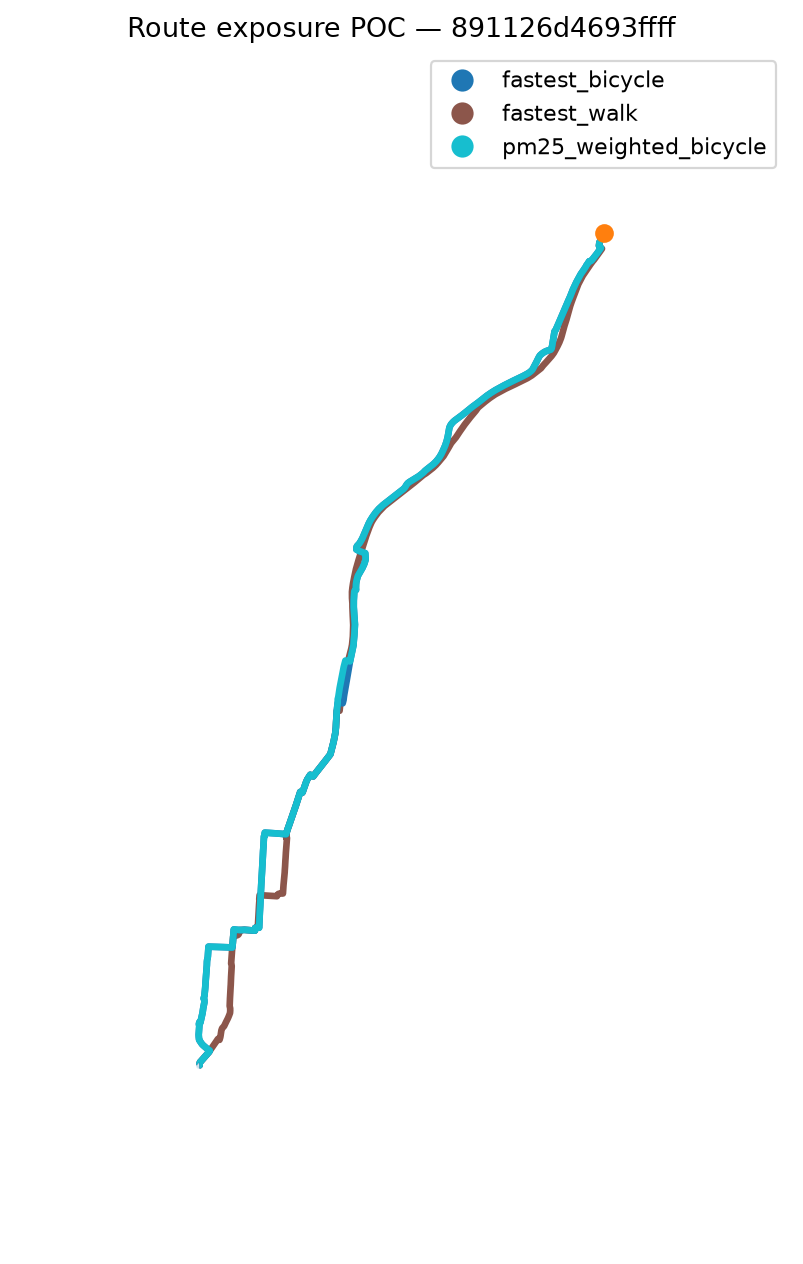

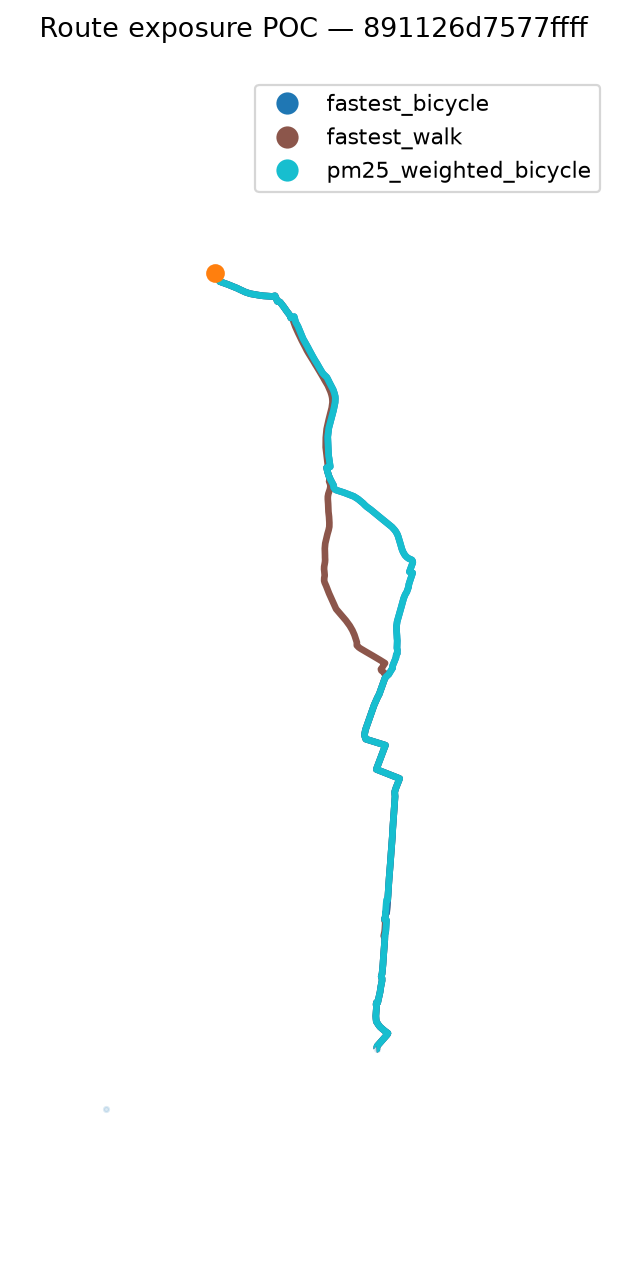

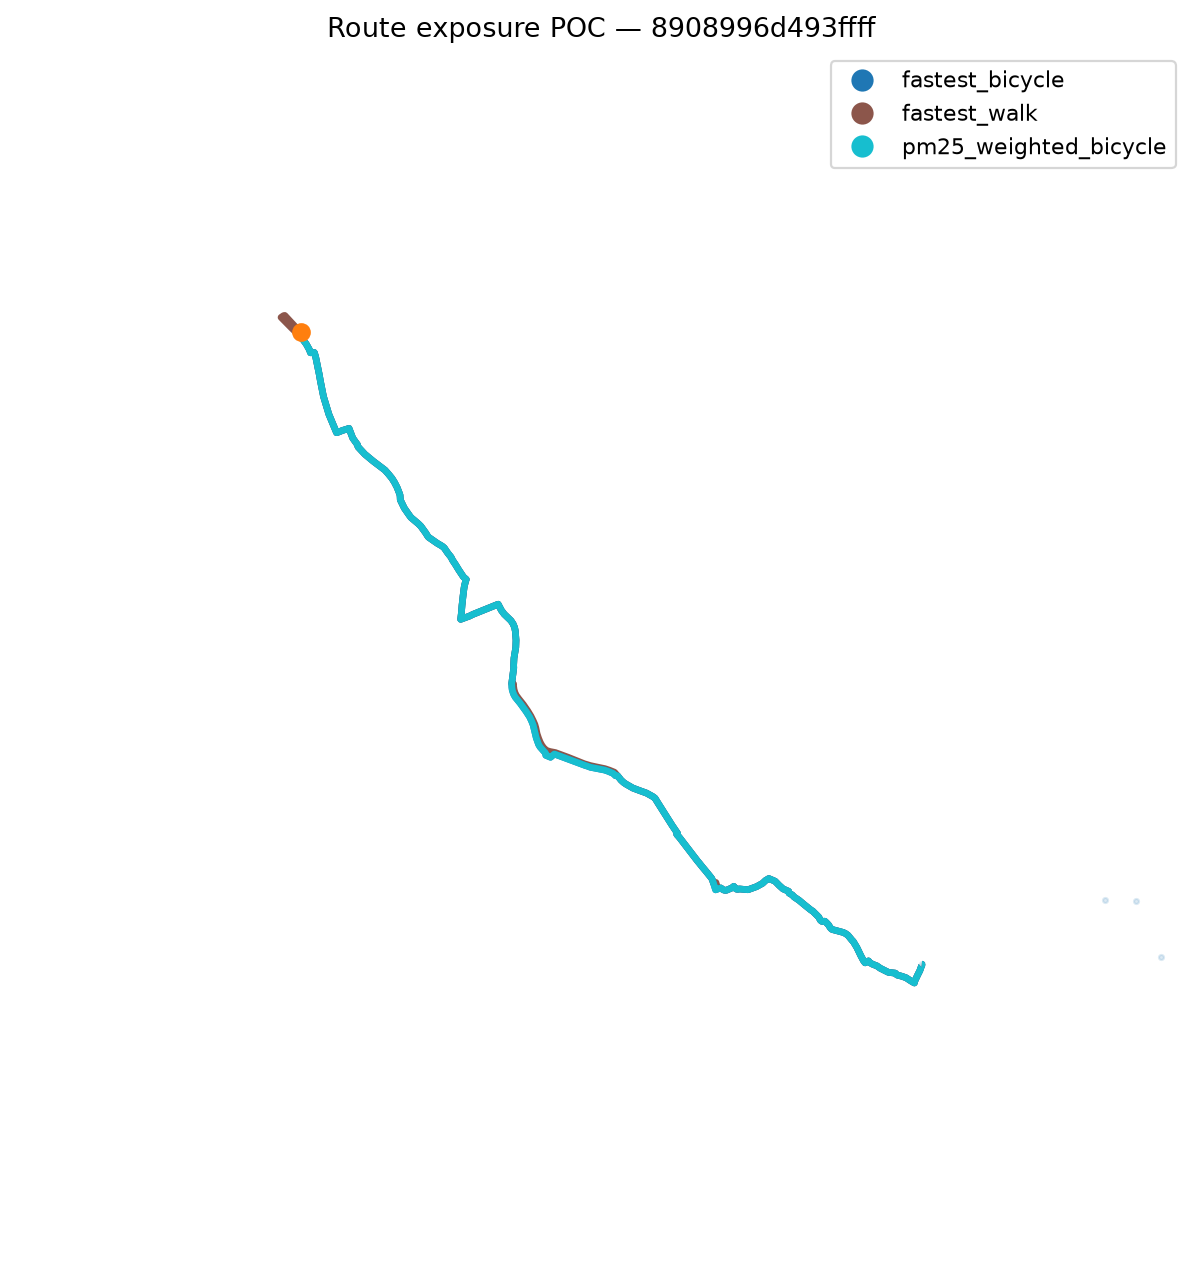

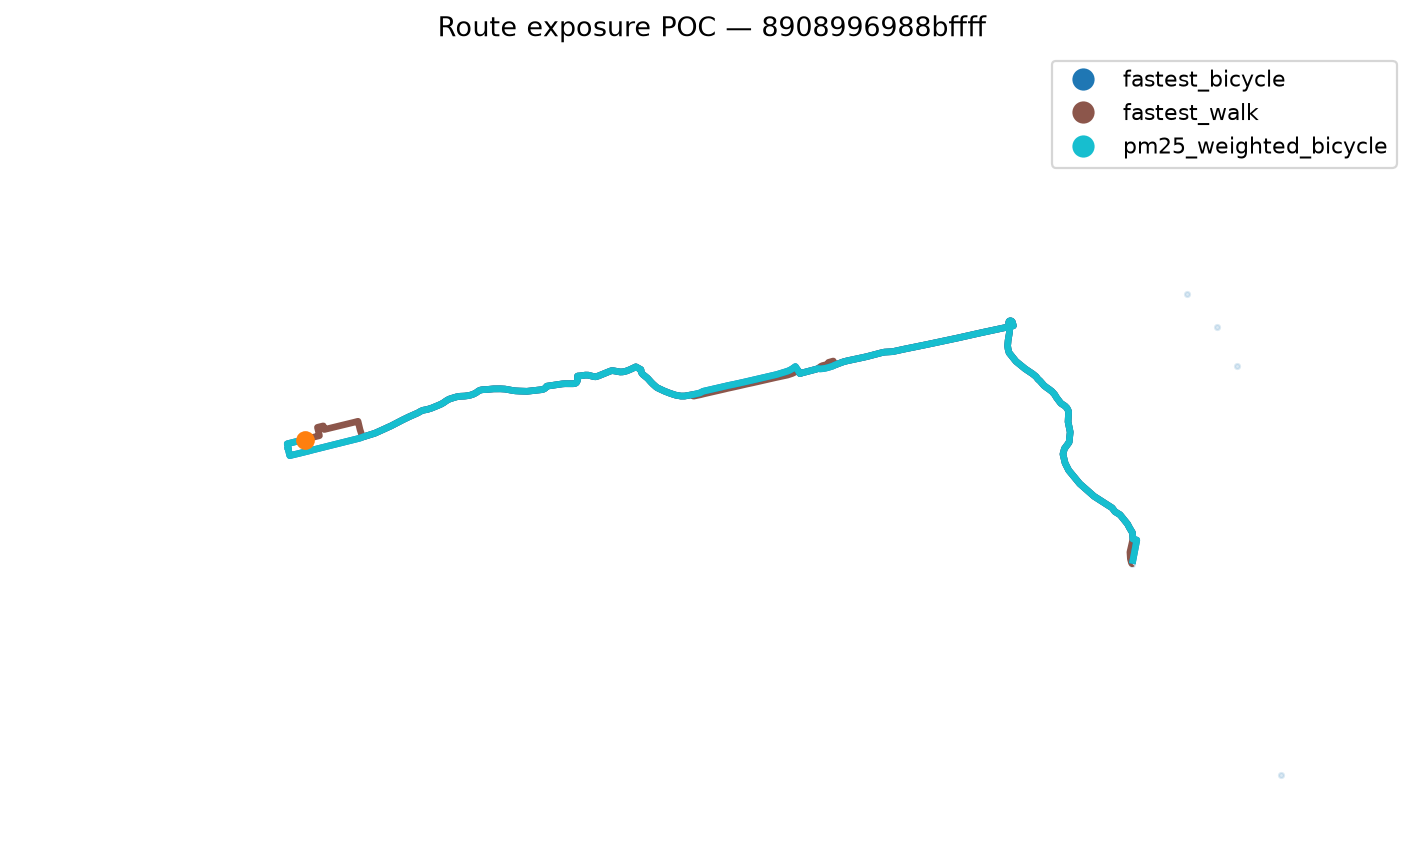

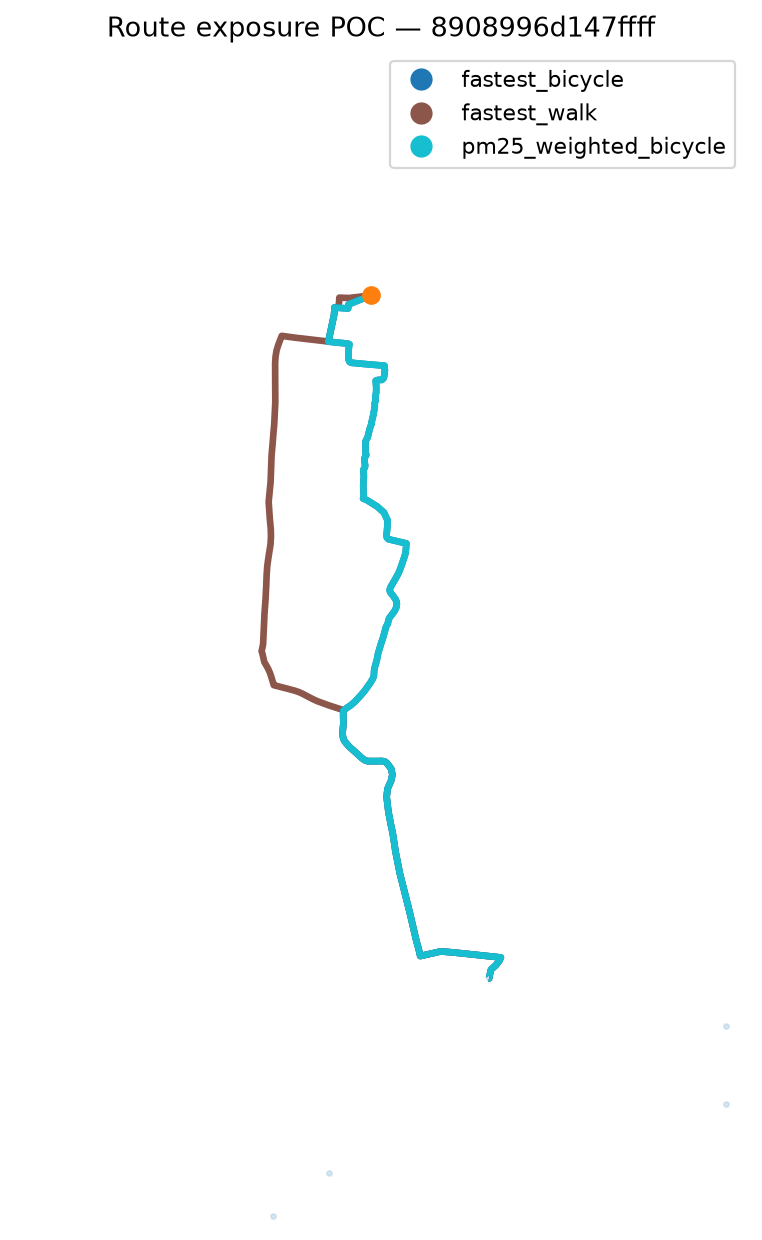

In [13]:
routes_map = routes.to_crs(
    "EPSG:3067"
)

origins_map = origin_points.to_crs(
    "EPSG:3067"
)

green_map = green_destinations.to_crs(
    "EPSG:3067"
)

for case_id in selected_cases["id"]:
    case_routes = routes_map.loc[
        routes_map["case_id"] == case_id
    ].copy()

    if case_routes.empty:
        continue

    fig, ax = plt.subplots(
        figsize=(9, 8),
        dpi=160,
    )

    green_map.plot(
        ax=ax,
        markersize=5,
        alpha=0.15,
    )

    origins_map.loc[
        origins_map["id"] == case_id
    ].plot(
        ax=ax,
        markersize=55,
        zorder=4,
    )

    case_routes.plot(
        ax=ax,
        column="route_choice",
        categorical=True,
        legend=True,
        linewidth=3,
    )

    minx, miny, maxx, maxy = (
        case_routes.total_bounds
    )

    pad = 800

    ax.set_xlim(
        minx - pad,
        maxx + pad,
    )
    ax.set_ylim(
        miny - pad,
        maxy + pad,
    )

    ax.set_title(
        f"Route exposure POC — {case_id}"
    )
    ax.set_axis_off()

    plt.tight_layout()
    plt.show()


## 14. Read the POC result

For each case, the important questions are:

1. **Behavioural context**
   - Was this H3 cell high-priority because activity was important and persistent?

2. **Environmental-opportunity context**
   - Was access to high-green-view destinations relatively weak?

3. **Route context**
   - How long is the fastest walking/cycling route?
   - What PM₂.₅, Green View, and road-noise conditions are encountered along it?

4. **Alternative-route context**
   - Can a slightly longer bicycle route reduce route-average PM₂.₅ in the sample-hour raster?

The purpose is not to establish historical exposure. The purpose is to prove that observed behavioural screening can be connected all the way through to route-level environmental conditions.


## 15. Final POC chain

At this point the proof-of-concept workflow is complete:

**Stage 06 — Locomizer behavioural response**
→ identify persistent/high-importance H3 cells

**Stage 07 — CAFEIN mobility context**
→ quantify walking/cycling accessibility

**Stage 08 — environmental opportunity access**
→ quantify access to high-green-view opportunities

**Stage 09 — route environmental exposure**
→ quantify PM₂.₅, Green View, and road-noise conditions along selected routes

A substantive future study can replace:
- sample-hour PM₂.₅ with historical event-specific air quality;
- high-green-view streets with validated cleaner-air/cooling/relief facilities;
- the exploratory accessibility burden with a validated transport-poverty framework.


## 16. Save outputs

In [14]:
routes_csv = (
    OUTPUT_DIR
    / "stage09_route_environmental_exposure.csv"
)

routes_gpkg = (
    OUTPUT_DIR
    / "stage09_route_environmental_exposure.gpkg"
)

summary_csv = (
    OUTPUT_DIR
    / "stage09_route_exposure_summary.csv"
)

bike_compare_csv = (
    OUTPUT_DIR
    / "stage09_bicycle_route_comparison.csv"
)

routes.drop(
    columns="geometry"
).to_csv(
    routes_csv,
    index=False,
)

routes.to_file(
    routes_gpkg,
    layer="route_environmental_exposure",
    driver="GPKG",
)

summary.to_csv(
    summary_csv,
    index=False,
)

bike_compare.to_csv(
    bike_compare_csv,
    index=False,
)

print("Saved:")
for p in [
    routes_csv,
    routes_gpkg,
    summary_csv,
    bike_compare_csv,
]:
    print(" -", p)


Saved:
 - ../outputs/v3/09_route_level_environmental_exposure/stage09_route_environmental_exposure.csv
 - ../outputs/v3/09_route_level_environmental_exposure/stage09_route_environmental_exposure.gpkg
 - ../outputs/v3/09_route_level_environmental_exposure/stage09_route_exposure_summary.csv
 - ../outputs/v3/09_route_level_environmental_exposure/stage09_bicycle_route_comparison.csv
